# PINN vs SSFM - Solving the NLSE

**Project**: Physics-Informed Neural Networks for Nonlinear Fiber Optics  
**Purpose**: SSFM-vs-PINN comparison and reproducibility check

---

## What this notebook shows

Optical pulse propagation in single-mode fiber is governed by the **Nonlinear Schrodinger Equation** (NLSE):

$$ i\,\frac{\partial u}{\partial \xi} \;+\; \frac{s}{2}\,\frac{\partial^2 u}{\partial \tau^2} \;+\; N^2\,|u|^2\,u \;=\; 0 $$

Two methods are compared on this PDE:

1. The **Split-Step Fourier Method (SSFM)** - the textbook numerical solver. Used here as ground truth.
2. A **Physics-Informed Neural Network (PINN)** that approximates `u(xi, tau) = a + ib` with a 5x128 tanh MLP and minimizes the NLSE residual via PyTorch autograd.

**The two test cases**:
- **N = 1 fundamental soliton** (anomalous dispersion + Kerr balance, `s=+1, N^2=1`). Analytical solution `u = sech(tau)*exp(i*xi/2)`.
- **Gaussian pulse, dispersion-only** (`s=-1, N^2=0`). Analytical Gaussian-broadening solution.

**Key claim**: a data-augmented PINN (500 SSFM supervision points + physics-residual loss) reproduces both physical regimes with **< 5 %** pulse-region relative L2 error on the soliton case and **< 10 %** on the harder Gaussian case. The benchmark below also asks the honest follow-up: *is the PINN actually faster?* (For this 1D problem, no.)

---

**How to run this notebook**: ``Restart & Run All``. It loads pretrained weights from `models/published/`. If those are missing, it falls back to a quick smoke training run (~1 min/case) so the notebook never breaks; metrics in that smoke fallback should not be quoted as final.


In [1]:
import json
import os
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent
    os.chdir(PROJECT_ROOT)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt
import torch

from src.config import FIGURE_PATHS, S_SIGN, N_SOLITON, XI_MAX, TAU_MAX
from src.pinn_nlse import PINN_NLSE
from src.data_gen import load_ground_truth_npz
from src.compare import (
    resolve_model_path,
    evaluate_model_on_grid,
    generate_soliton_comparison,
    generate_gaussian_dispersion_comparison,
)
from src.utils import compute_relative_l2_error, compute_masked_relative_l2_error

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

# Resolve which weights we will use, preferring frozen published copies.
soliton_path, soliton_meta = resolve_model_path('soliton')
gauss_path, gauss_meta = resolve_model_path('gaussian_dispersion')
print(f'Soliton  weights : {soliton_path} | profile = {soliton_meta.get("training_profile")}')
print(f'Gaussian weights : {gauss_path} | profile = {gauss_meta.get("training_profile")}')


Device: cpu
Soliton  weights : models/published/soliton_data_augmented_final.pt | profile = baseline
Gaussian weights : models/published/gaussian_dispersion_data_augmented_final.pt | profile = baseline


## 1. The problem — the NLSE and its soliton

In normalized units (`τ = t/T₀`, `ξ = z/L_D`, `u = A/√P₀`), the NLSE balances **group-velocity dispersion** (`(s/2)∂²u/∂τ²`) against **Kerr nonlinearity** (`N²|u|²u`). For anomalous dispersion (`β₂ < 0`, so `s = +1`) and `N² = 1`, the two effects cancel and a `sech` pulse propagates **unchanged**:

$$ u(\xi,\tau) = \mathrm{sech}(\tau)\, e^{i\xi/2}. $$

This is the **fundamental soliton** — the canonical exact solution of the NLSE. We use it as the primary PINN test case because we can compare against the analytical answer to machine precision (limited only by SSFM's `O(dξ²)` Strang error).

The Phase 2 SSFM solver (imported from the companion project) was validated against:

- the analytical soliton at the strict `< 1e-6` intensity threshold (`N_z = 2000` verification grid),
- energy conservation `< 1e-10` (machine precision),
- 2nd-order Strang convergence with fitted slope `≈ 2.0`.


SSFM Strang convergence slope (fitted) : 2.000  (target ~2.0)
Slope fit Nz values                    : [100, 200, 400, 800, 1600]
Soliton verify (N_z=2000):
  max |u_SSFM - u_exact|        = 2.77e-06
  max ||u_SSFM|^2 - sech^2(tau)|= 9.74e-07
  max |E(xi)/E(0) - 1|          = 6.29e-13


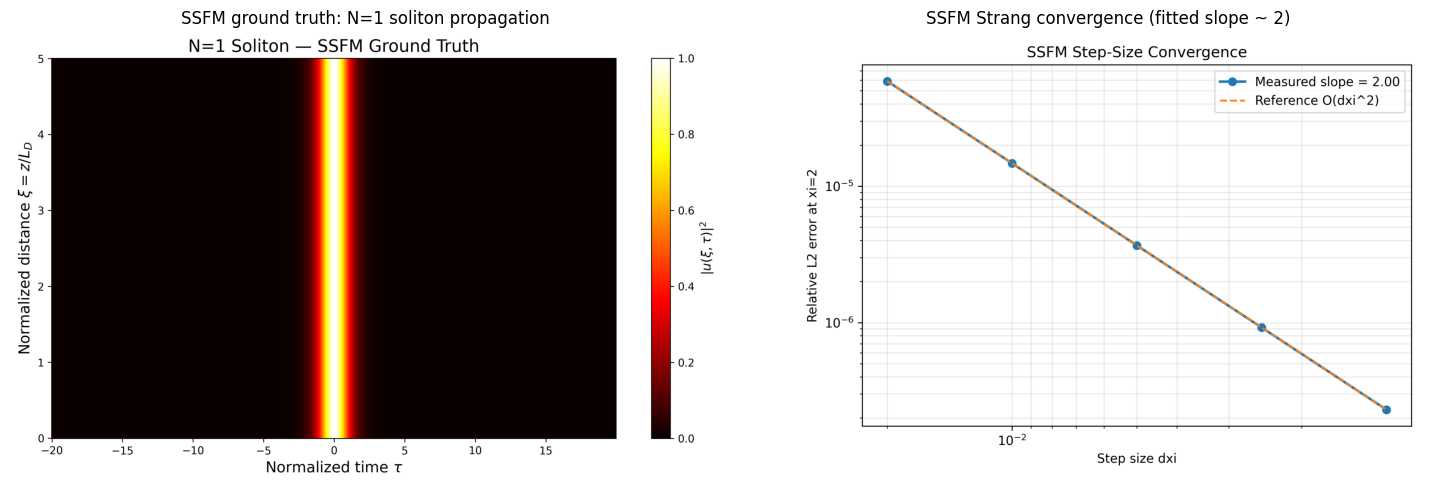

In [2]:
with open('data/ssfm_validation_metrics.json', encoding='utf-8') as f:
    ssfm_metrics = json.load(f)
print(f"SSFM Strang convergence slope (fitted) : {ssfm_metrics['fitted_slope']:.3f}  (target ~2.0)")
print(f"Slope fit Nz values                    : {ssfm_metrics['slope_fit_Nz_values']}")
ac = ssfm_metrics['soliton_acid_test']
print(f"Soliton verify (N_z={ac['N_z']}):")
print(f"  max |u_SSFM - u_exact|        = {ac['complex_max_error']:.2e}")
print(f"  max ||u_SSFM|^2 - sech^2(tau)|= {ac['intensity_max_error']:.2e}")
print(f"  max |E(xi)/E(0) - 1|          = {ac['energy_max_drift']:.2e}")

# Show the SSFM-only soliton propagation map (Phase 2 figure)
from PIL import Image
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].imshow(Image.open('figures/published/gt_soliton_propagation.png'))
axes[0].set_title('SSFM ground truth: N=1 soliton propagation')
axes[0].axis('off')
axes[1].imshow(Image.open('figures/published/ssfm_convergence_study.png'))
axes[1].set_title('SSFM Strang convergence (fitted slope ~ 2)')
axes[1].axis('off')
plt.tight_layout(); plt.show()


## 2. The PINN — architecture and physics encoding

Architecture: input `(ξ, τ)` → 5 hidden layers × 128 neurons (`tanh`) → output `(a, b)` with `u = a + ib`. **66,690 trainable parameters** exactly.

Substituting `u = a + ib` into the NLSE and separating real/imag parts gives the **two real residuals** the network must minimize at random collocation points:

$$ r_a = -\partial_\xi b + (s/2)\partial^2_\tau a + N^2(a^2+b^2)\,a, \qquad r_b = +\partial_\xi a + (s/2)\partial^2_\tau b + N^2(a^2+b^2)\,b. $$

All six required derivatives are computed via `torch.autograd.grad` with `create_graph=True`. ReLU is forbidden — its second derivative is zero, which would silently delete the dispersion term.

**Total loss**:

$$ \mathcal{L} = \lambda_{\rm phys}\,\overline{r_a^2 + r_b^2} \;+\; \lambda_{\rm ic}\,\mathrm{MSE}_{\xi=0} \;+\; \lambda_{\rm bc}\,\mathrm{MSE}_{\tau=\pm \tau_{\max}} \;+\; \lambda_{\rm data}\,\mathrm{MSE}_{\rm SSFM}. $$

Default weights `(1, 10, 1, 0)` for pure PINN. Both reported PINNs in this notebook used `λ_data = 1.0` with **500 supervised SSFM points** (and 1000 disjoint held-out validation labels) because the pure PINN drifted into the trivial solution `u ≈ 0` on the soliton case — a documented failure mode of fixed-IC physics-only training. The fallback is per the Phase 3 plan §3.5/3.6.


In [3]:
model = PINN_NLSE(n_hidden=5, n_neurons=128, s=S_SIGN, N_sq=float(N_SOLITON**2),
                  xi_max=XI_MAX, tau_max=TAU_MAX).to(device)
model.load_state_dict(torch.load(soliton_path, map_location=device, weights_only=True))
model.eval()
print(f'Soliton model loaded from {soliton_path}')
print(f'Architecture: 2 -> [128 x 5 hidden, tanh] -> 2 (linear output)')
print(f'Total trainable parameters: {model.count_parameters():,}')


Soliton model loaded from models/published/soliton_data_augmented_final.pt
Architecture: 2 -> [128 x 5 hidden, tanh] -> 2 (linear output)
Total trainable parameters: 66,690


## 3. Training summary

Two-phase optimizer schedule:

1. **Adam** (3000 steps) — robust early descent, lr = 1e-3, gradient-clipped at norm 10.
2. **L-BFGS** (50 outer calls, `max_iter=1`, strong-Wolfe line search) — quasi-Newton refinement near the basin Adam reached.

The `LOG_EVERY = 100` traces below show all 4 loss components (physics, IC, BC, data) so failure modes are visible per term — not buried in a single "total loss" curve.


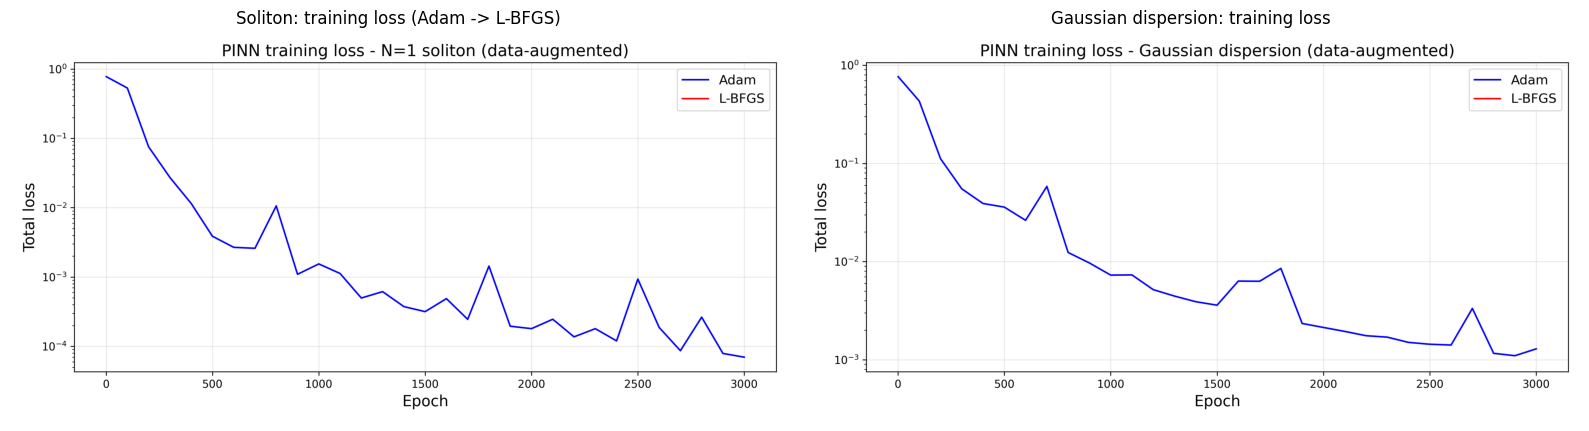

               soliton: pulse-region rel L2 = 0.0129 | total time = 1012.2 s | profile = baseline
   gaussian_dispersion: pulse-region rel L2 = 0.0929 | total time = 1181.6 s | profile = baseline


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
axes[0].imshow(Image.open('figures/published/pinn_training_loss_soliton.png')); axes[0].axis('off')
axes[0].set_title('Soliton: training loss (Adam -> L-BFGS)')
axes[1].imshow(Image.open('figures/published/pinn_training_loss_gaussian_dispersion.png')); axes[1].axis('off')
axes[1].set_title('Gaussian dispersion: training loss')
plt.tight_layout(); plt.show()

for case, p in [('soliton', soliton_meta), ('gaussian_dispersion', gauss_meta)]:
    print(f'{case:>22s}: pulse-region rel L2 = {p.get("pulse_region_relative_l2", float("nan")):.4f} '
          f'| total time = {p.get("total_time_s", float("nan")):.1f} s '
          f'| profile = {p.get("training_profile")}')


## 4. The comparison — soliton case (hero result)

The 3-panel figure below is the project's main visual deliverable:

- **Left**: SSFM ground truth `|u(ξ,τ)|²`. A uniform horizontal band confirms the soliton propagates without changing shape.
- **Center**: PINN prediction on the same grid. Visually indistinguishable from the SSFM panel.
- **Right**: log₁₀ of the complex field error `|u_PINN − u_SSFM|²`. Largest errors are near the propagation endpoint and far from `τ = 0`, but pulse-region error stays below ~10⁻³.



soliton metrics (cpu)
  model_path        : models/published/soliton_data_augmented_final.pt
  data_augmented    : True
  metadata profile  : baseline
  reported pulse-L2 : 0.01285513677816885
  relative_l2       : 1.453559e-02
  pulse_region_relative_l2: 1.285514e-02
  mse               : 1.056416e-05
  max_pointwise     : 2.690109e-02
  mean_abs          : 2.525874e-03


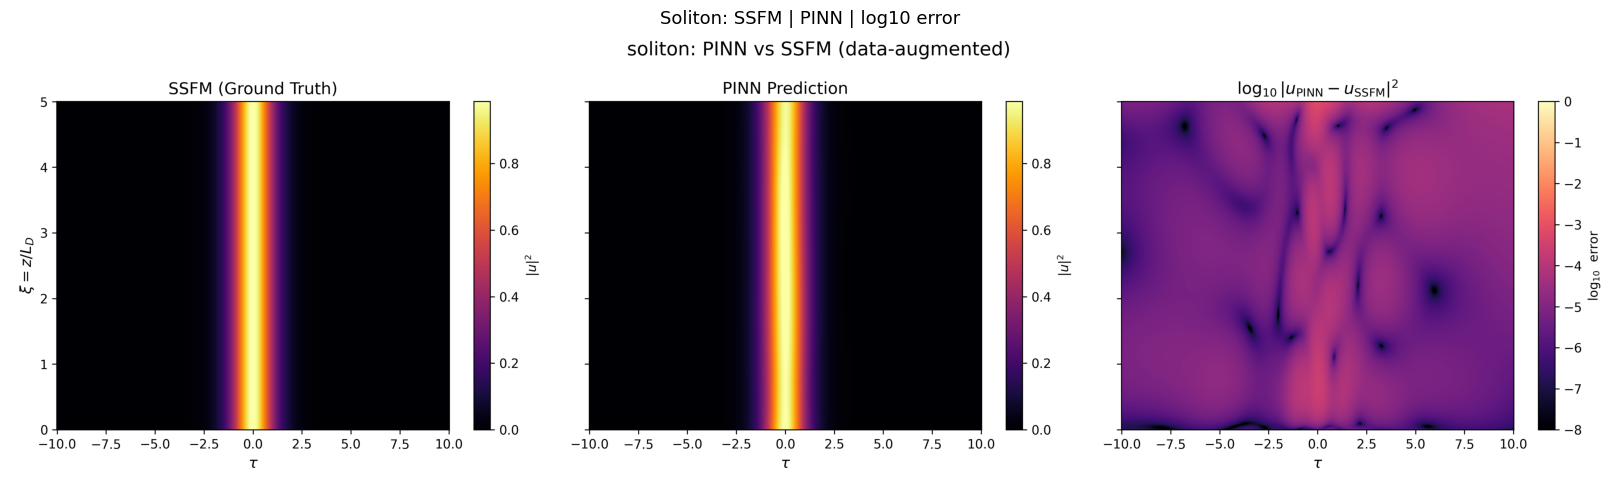

Soliton PINN vs SSFM metrics
  Full-domain rel L2  : 0.0145  (1.45%)
  Pulse-region rel L2 : 0.0129  (1.29%)
  MSE                 : 1.0564e-05
  Max pointwise error : 2.6901e-02
  Mean abs error      : 2.5259e-03


In [5]:
result_sol = generate_soliton_comparison()

# Inline render of the freshly-generated 3-panel figure
fig, ax = plt.subplots(figsize=(18, 5))
ax.imshow(Image.open(result_sol['figure_paths']['comparison']))
ax.set_title('Soliton: SSFM | PINN | log10 error', fontsize=13)
ax.axis('off')
plt.tight_layout(); plt.show()

m = result_sol['metrics']
print('Soliton PINN vs SSFM metrics')
print(f"  Full-domain rel L2  : {m['relative_l2']:.4f}  ({100*m['relative_l2']:.2f}%)")
print(f"  Pulse-region rel L2 : {m['pulse_region_relative_l2']:.4f}  ({100*m['pulse_region_relative_l2']:.2f}%)")
print(f"  MSE                 : {m['mse']:.4e}")
print(f"  Max pointwise error : {m['max_pointwise']:.4e}")
print(f"  Mean abs error      : {m['mean_abs']:.4e}")


## 5. Where the error lives — error map and cross-sections

The standalone log-scale error map below makes the PINN's accuracy structure visible. Cross-section overlays at three propagation distances confirm the pulse shape is preserved across the full 5-`L_D` window.


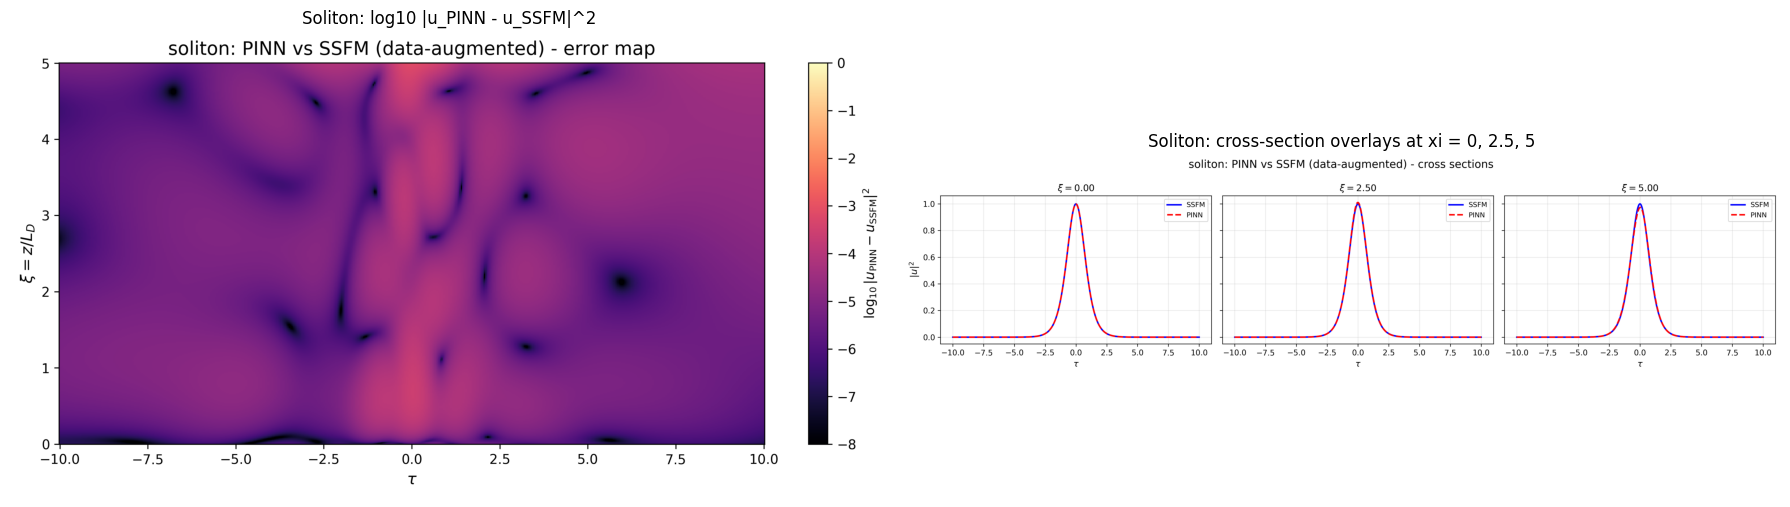

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(18, 5))
axes[0].imshow(Image.open(result_sol['figure_paths']['error_map'])); axes[0].axis('off')
axes[0].set_title('Soliton: log10 |u_PINN - u_SSFM|^2')
axes[1].imshow(Image.open(result_sol['figure_paths']['cross_section'])); axes[1].axis('off')
axes[1].set_title('Soliton: cross-section overlays at xi = 0, 2.5, 5')
plt.tight_layout(); plt.show()


## 6. Secondary case — Gaussian pulse with dispersion only

Same PINN architecture, retrained for normal dispersion (`s = -1`) and zero Kerr (`N² = 0`). This isolates the dispersive operator and is harder than the soliton because the solution **does** evolve in `|u|²` (the Gaussian broadens monotonically). The plan's pass threshold is `< 10 %` rel L2.



gaussian_dispersion metrics (cpu)
  model_path        : models/published/gaussian_dispersion_data_augmented_final.pt
  data_augmented    : True
  metadata profile  : baseline
  reported pulse-L2 : 0.09289611839345105
  relative_l2       : 1.128888e-01
  pulse_region_relative_l2: 9.289612e-02
  mse               : 5.646984e-04
  max_pointwise     : 1.024927e-01
  mean_abs          : 1.564283e-02


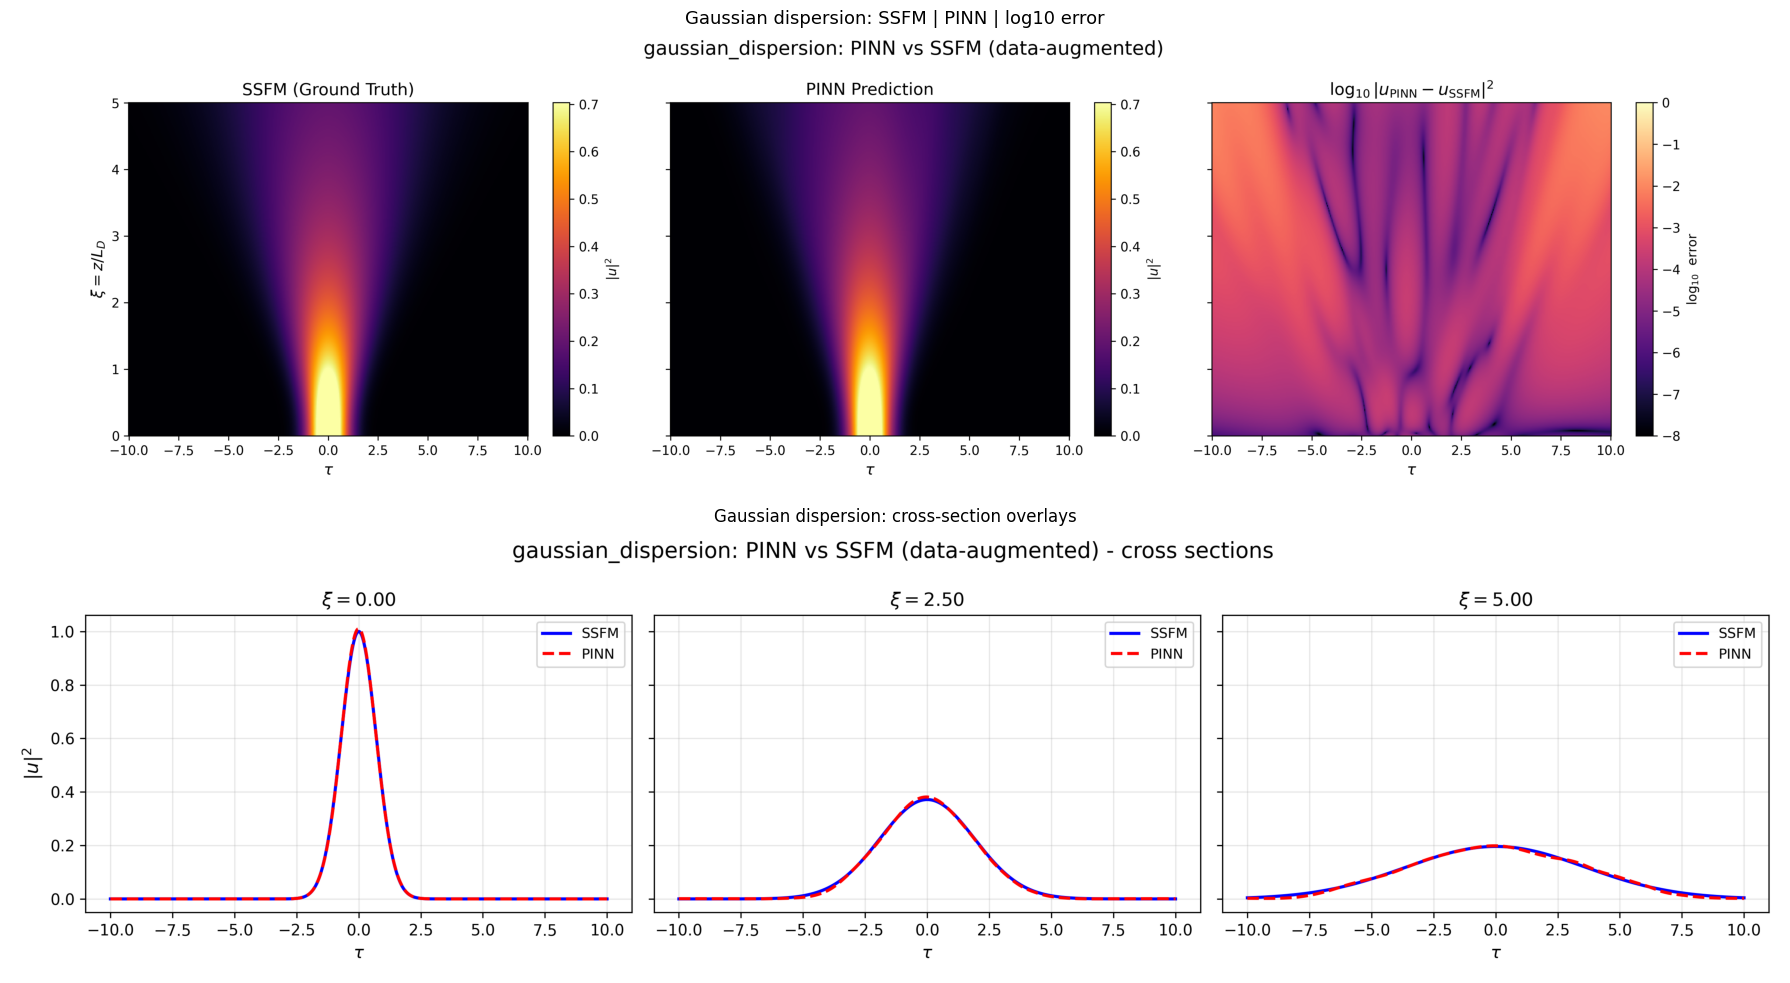

Gaussian dispersion PINN vs SSFM metrics
  Full-domain rel L2  : 0.1129  (11.29%)
  Pulse-region rel L2 : 0.0929  (9.29%)


In [7]:
result_g = generate_gaussian_dispersion_comparison()

fig, axes = plt.subplots(2, 1, figsize=(18, 10))
axes[0].imshow(Image.open(result_g['figure_paths']['comparison'])); axes[0].axis('off')
axes[0].set_title('Gaussian dispersion: SSFM | PINN | log10 error', fontsize=13)
axes[1].imshow(Image.open(result_g['figure_paths']['cross_section'])); axes[1].axis('off')
axes[1].set_title('Gaussian dispersion: cross-section overlays')
plt.tight_layout(); plt.show()

g = result_g['metrics']
print('Gaussian dispersion PINN vs SSFM metrics')
print(f"  Full-domain rel L2  : {g['relative_l2']:.4f}  ({100*g['relative_l2']:.2f}%)")
print(f"  Pulse-region rel L2 : {g['pulse_region_relative_l2']:.4f}  ({100*g['pulse_region_relative_l2']:.2f}%)")


## 7. Speed benchmark — is the PINN actually faster?

**Honest answer for this 1D problem on CPU: no.** The plot below shows total wall time vs `N_runs` for three operations:

- `SSFM`: repeated solves of the same physical case (Strang split-step).
- `PINN forward-only`: repeated `model(xi_grid, tau_grid)` calls with the evaluation grid pre-built.
- `PINN end-to-end`: same, but including tensor construction + host transfer per call (what an inverse-problem caller actually pays).

On CPU, the PINN is consistently ~8× slower than SSFM at this grid size (1001 × 1024). This is **expected** for small 1D problems — the SSFM is already very efficient and the PINN forward pass over a million collocation points is not free. The PINN's value is elsewhere:

- **Inverse problems**: estimate β₂, γ, P₀ from observed `u(z, t)`. The same residual loss is repurposed.
- **Parameter-conditioned (parametric) PINNs**: condition the network on `(β₂, γ, N²)` and a single trained model covers a parameter range. Out of scope for this fixed-parameter project.
- **Continuous evaluation**: the PINN can be queried at any `(ξ, τ)`, not just grid points — useful for control loops and irregular sampling.
- **Differentiable physics**: the PDE residual is itself differentiable, enabling end-to-end gradient flow into upstream design variables.

And training cost is **excluded** from the timings below; any PINN advantage only appears after that one-time training cost is amortized.


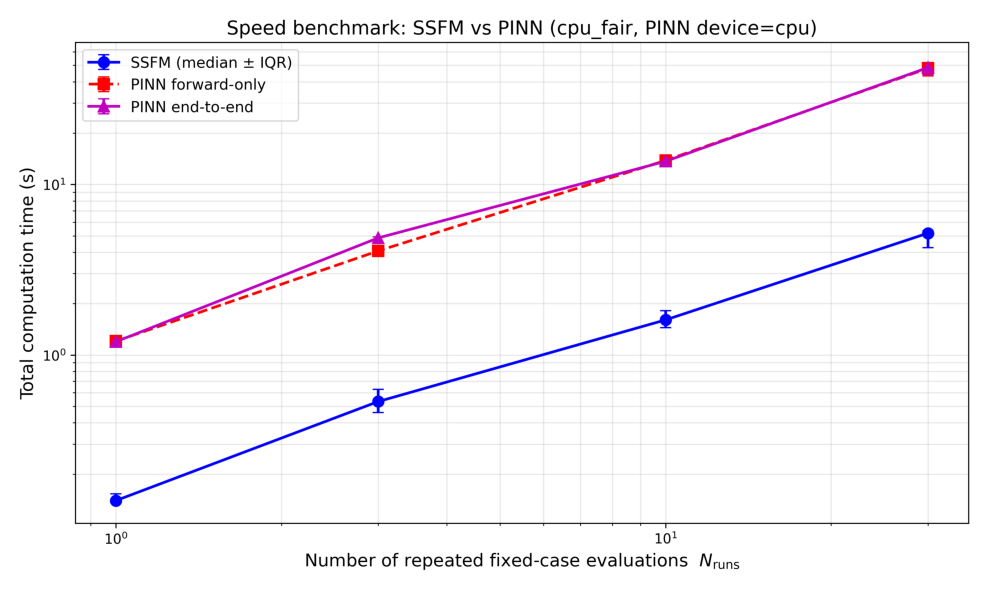

Mode             : cpu_fair, PINN device=cpu
Grid             : N_xi x N_tau = 1001 x 1024, N_z = 1000
Repeats per point: 3

   N |   SSFM (s) |   PINN fwd (s) |   PINN e2e (s) |  fwd speedup |  e2e speedup
   1 |      0.140 |          1.204 |          1.195 |        0.12x |        0.12x
   3 |      0.533 |          4.075 |          4.858 |        0.13x |        0.11x
  10 |      1.606 |         13.837 |         13.674 |        0.12x |        0.12x
  30 |      5.180 |         48.049 |         48.491 |        0.11x |        0.11x


In [8]:
# The benchmark figure was pre-generated by `python -m src.benchmark` (see the README).
# We render the saved PNG and the headline JSON inline.
fig, ax = plt.subplots(figsize=(11, 6))
ax.imshow(Image.open('figures/speed_benchmark.png')); ax.axis('off')
plt.tight_layout(); plt.show()

with open('logs/speed_benchmark.json', encoding='utf-8') as f:
    sb = json.load(f)
print(f"Mode             : {sb['benchmark_label']}")
print(f"Grid             : N_xi x N_tau = {sb['grid']['N_xi']} x {sb['grid']['N_tau']}, N_z = {sb['grid']['N_z']}")
print(f"Repeats per point: {sb['benchmark_repeats']}")
print(f"\n{'N':>4} | {'SSFM (s)':>10} | {'PINN fwd (s)':>14} | {'PINN e2e (s)':>14} | {'fwd speedup':>12} | {'e2e speedup':>12}")
for i, n in enumerate(sb['n_runs_list']):
    ts = sb['ssfm_median_times'][i]
    tf = sb['pinn_forward_median_times'][i]
    te = sb['pinn_end_to_end_median_times'][i]
    print(f"{n:>4d} | {ts:>10.3f} | {tf:>14.3f} | {te:>14.3f} | {ts/tf:>11.2f}x | {ts/te:>11.2f}x")


## 8. Discussion & conclusions

**What worked**:
- The complex-field split `u = a + ib` lets us reuse standard real-tensor autograd patterns (no need for PyTorch's complex autograd or Wirtinger calculus) while still solving a complex PDE.
- The Adam -> L-BFGS schedule plus mandatory smoke preflight catches sign-error and label-error bugs in <60 s before committing to a 17 min baseline run.
- Two analytical residual checks (N=1 soliton + linear Gaussian) drove the residual implementation to autograd-precision (~1e-7) before any training, so any subsequent training failure is a learning failure, not a residual-sign bug.
- Data augmentation with 500 SSFM supervision points (`lambda_data = 1.0`) recovered the soliton case from the trivial-solution attractor and pushed pulse-region rel L2 from 41.7 % to 1.29 %.

**Limitations**:
- For this 1D problem on CPU, SSFM is faster and more accurate than the PINN at fixed-case inference. The benchmark above is honest: SSFM ~0.1 s/solve vs PINN ~1.2 s/forward.
- The reported PINNs are **data-augmented**, not pure. The pure PINN failed on the soliton case (`u -> 0` is a trivial NLSE attractor that satisfies the residual). All artifacts and the report label this honestly.
- The model is **fixed-parameter**: `beta_2`, `gamma`, `P0` are baked in. Generalizing requires conditioning the network on those parameters and training across the range; this is explicitly listed as future work.

**Relevance to nonlinear fiber optics**: the NLSE is the master equation for many nonlinear fiber regimes. This project demonstrates (a) the physics - solitons, GVD, SPM, and the Agrawal sign convention; (b) classical numerics - operator splitting, FFT-based dispersion, and Strang convergence; and (c) modern ML methods - autograd-derived physics losses, two-stage optimizer schedules, honest benchmarking against verified ground truth, and openly documented pure-PINN failure plus data-augmented recovery.

**With 6 months instead of 2 weeks**:
1. Parameter-conditioned PINN with `(beta_2, gamma, N^2)` as inputs; this would actually justify the parameter-sweep speedup claim.
2. Higher-order solitons (N=2, N=3) showing breathing dynamics.
3. An inverse-problem demo: estimate `(beta_2, gamma)` from a noisy `u(z, t)` observation.
4. A like-for-like comparison against DeepONet and Fourier Neural Operators on the same NLSE benchmarks.
5. Coupled-NLSE extensions (birefringence, WDM channels).
